## DS605: Fundamentals of Machine Learning

## Lab Assignment - 6

## Feature Extraction and Machine Learning with Image and Text Data

### Name: Puranik Aryan Hitesh
### StudentID: 202618030


**Steps:** 1. Load data → 2. Train/test split → 3. Preprocessing (Grayscale → Blur → Black-hat → Normalize → Threshold) → 4. Feature extraction → 5. Training (Logistic Regression & Random Forest) → 6. Testing → 7. Performance metrics


### Part A - Image Feature Extraction and Classification

In [1]:
import os, glob, time
from collections import Counter

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt


# from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
#                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
#                              classification_report)

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

## Settings

In [3]:
# >>> CHANGE THIS: folder that contains the sub-folders  crack/  and  no_crack/ <<<
DATA_DIR = r"..\data"

IMG_SIZE    = 256          # every image is resized to IMG_SIZE x IMG_SIZE
BLUR_KSIZE  = (9, 9)       # Gaussian blur window (odd numbers)
KERNEL_SIZE = (21, 21)     # black-hat kernel: slightly wider than the widest crack
DARK_T      = 80           # gray level below this  = "dark pixel"
BRIGHT_T    = 160          # gray level above this  = "bright pixel"
CANNY_LOW, CANNY_HIGH = 50, 150
MIN_COMPONENT_AREA = 30    # ignore mask blobs smaller than this (pixels)
GRID        = 4            # GRID x GRID spatial features
TEST_SIZE   = 0.2
SEED        = 42
EXTS = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")

## Step 1 - Load the data

In [4]:
images, y_all, paths_all = [], [], []
shape_counter = Counter()

for label, folder in [(1, "crack"), (0, "no_crack")]:
    files = []
    for ext in EXTS:
        files += glob.glob(os.path.join(DATA_DIR, folder, ext))
    files = sorted(files)
    if len(files) == 0:
        raise FileNotFoundError(f"No images found in {os.path.join(DATA_DIR, folder)}")

    for path in files:
        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        if img is None:
            print("Skipping unreadable file:", path)
            continue
        shape_counter[(img.shape, str(img.dtype))] += 1      # inspect original shape / dtype

        if img.ndim == 2:                                    # grayscale file -> 3 channels
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        elif img.shape[2] == 4:                              # BGRA -> BGR
            img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
        if img.dtype != np.uint8:                            # e.g. 16-bit -> 8-bit
            img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        images.append(img)
        y_all.append(label)
        paths_all.append(path)

y_all = np.array(y_all)

print(f"Loaded {len(images)} images  |  crack = {int((y_all == 1).sum())}  |  no_crack = {int((y_all == 0).sum())}")
print("\nOriginal image dimensions / channels / dtype:")
for (shape, dtype), c in shape_counter.most_common(5):
    ch = shape[2] if len(shape) == 3 else 1
    print(f"  {c:4d} images | H x W = {shape[0]} x {shape[1]} | channels = {ch} | dtype = {dtype}")

Loaded 400 images  |  crack = 200  |  no_crack = 200

Original image dimensions / channels / dtype:
   400 images | H x W = 448 x 448 | channels = 3 | dtype = uint8


## Step 2 - Train / test split
The split is done **once** here. Both Logistic Regression and Random Forest will use exactly these same train and test images. It is stratified so both sets keep the same crack / no-crack ratio.

In [5]:
idx = np.arange(len(images))
idx_train, idx_test = train_test_split(idx, test_size=TEST_SIZE, stratify=y_all, random_state=SEED)

train_imgs = [images[i] for i in idx_train]
test_imgs  = [images[i] for i in idx_test]
y_train, y_test = y_all[idx_train], y_all[idx_test]

print(f"Train: {len(train_imgs)} images (crack={int(y_train.sum())}, no_crack={int((y_train == 0).sum())})")
print(f"Test : {len(test_imgs)} images (crack={int(y_test.sum())}, no_crack={int((y_test == 0).sum())})")

Train: 320 images (crack=160, no_crack=160)
Test : 80 images (crack=40, no_crack=40)


## Step 3 - Preprocessing
Resize → Grayscale → Gaussian Blur → Black-hat → Normalize → Threshold

| Stage | Purpose |
|---|---|
| Grayscale | one intensity channel |
| Blur | remove noise |
| Black-hat | isolate small dark details (cracks) |
| Normalize | stretch the response to 0-255 so it is visible |
| Threshold (Otsu) | binary crack mask |


In [6]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, KERNEL_SIZE)

stages = {}            # stages["train"]["gray"] -> list of images, etc.
t_preproc = {}

for split_name, imgs in [("train", train_imgs), ("test", test_imgs)]:
    t0 = time.perf_counter()
    gray_l, blur_l, blackhat_l, proc_l, mask_l = [], [], [], [], []

    for img in imgs:
        img_r = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)   # common size
        gray  = cv2.cvtColor(img_r, cv2.COLOR_BGR2GRAY)                               # Grayscale
        blur  = cv2.GaussianBlur(gray, BLUR_KSIZE, 0)                                 # Blur
        blackhat  = cv2.morphologyEx(blur, cv2.MORPH_BLACKHAT, kernel)                # Black-hat
        processed = cv2.normalize(blackhat, None, 0, 255, cv2.NORM_MINMAX)            # Normalize
        _, mask = cv2.threshold(processed, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)  # Threshold

        gray_l.append(gray); blur_l.append(blur); blackhat_l.append(blackhat)
        proc_l.append(processed); mask_l.append(mask)

    stages[split_name] = {"gray": gray_l, "blur": blur_l, "blackhat": blackhat_l,
                          "processed": proc_l, "mask": mask_l}
    t_preproc[split_name] = time.perf_counter() - t0
    print(f"{split_name}: preprocessed {len(imgs)} images in {t_preproc[split_name]:.2f} s")

train: preprocessed 320 images in 1.06 s
test: preprocessed 80 images in 0.27 s


**Check the stages visually** - one crack image and one clean image from the training set. If the cracks are not clear in the black-hat panel, adjust `KERNEL_SIZE` in Settings and rerun from Step 3.

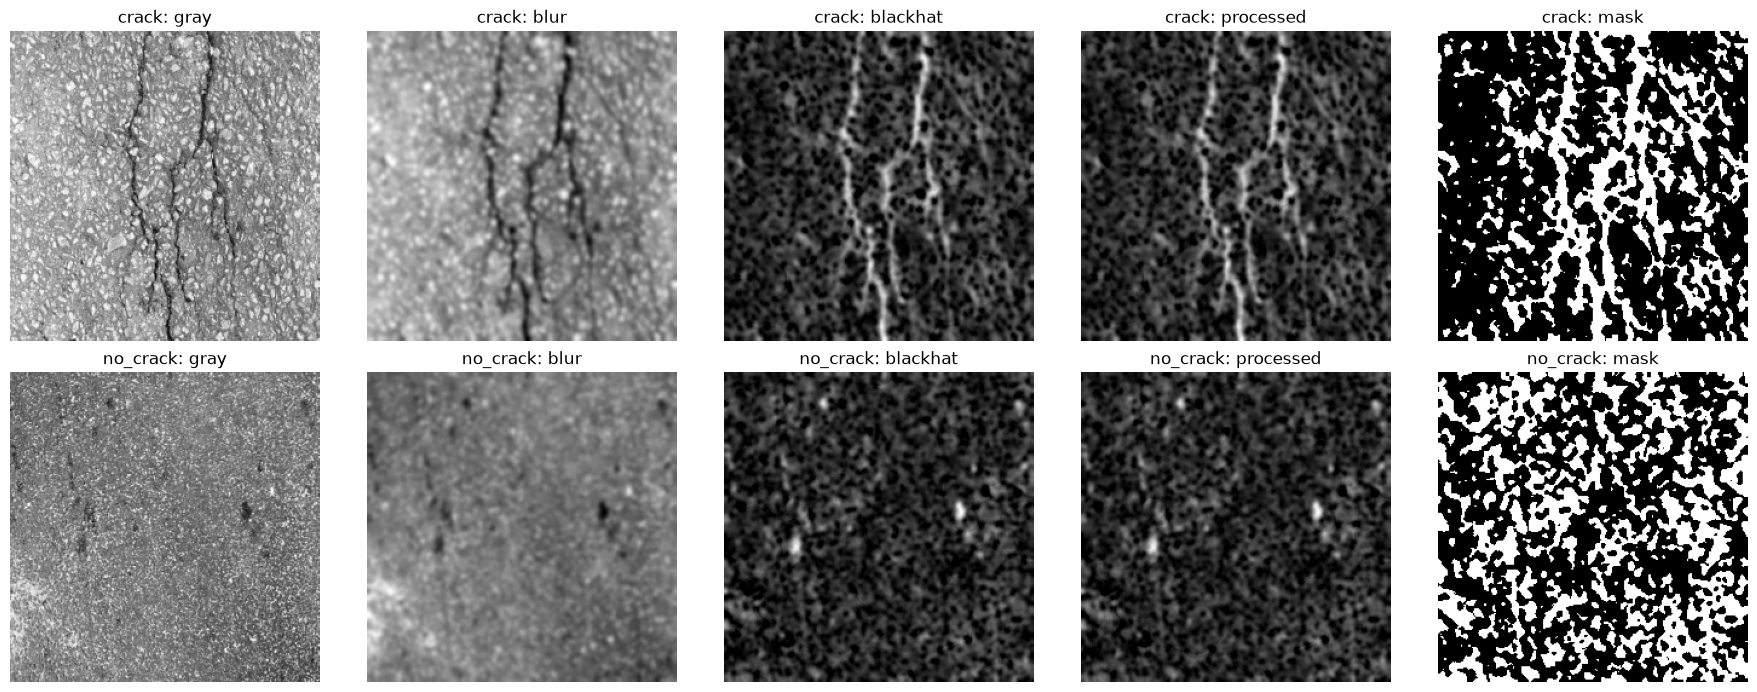

In [7]:
names = ["gray", "blur", "blackhat", "processed", "mask"]
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for row, (lbl, title) in enumerate([(1, "crack"), (0, "no_crack")]):
    k = int(np.where(y_train == lbl)[0][0])
    for col, nm in enumerate(names):
        axes[row, col].imshow(stages["train"][nm][k], cmap="gray")
        axes[row, col].set_title(f"{title}: {nm}")
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()

## Step 4 - Feature extraction (one feature row per image)
Classical models cannot take an image directly, so each preprocessed image becomes a row of numbers:

- **`int_*`** - NumPy intensity statistics (mean brightness, contrast, dark/bright-pixel ratio, percentiles, skewness, ...)
- **`edge_*`** - Canny edge count and density
- **`bh_*`** - black-hat response statistics and crack-mask shape (blob count, size, length, spatial density)

In [8]:
cell = IMG_SIZE // GRID
feature_dfs = {}
t_feat = {}

for split_name in ["train", "test"]:
    t0 = time.perf_counter()
    S = stages[split_name]
    rows = []

    for gray, blur, blackhat, processed, mask_img in zip(S["gray"], S["blur"], S["blackhat"], S["processed"], S["mask"]):
        row = {}

        # ---------- (a) intensity features (NumPy) on the grayscale image ----------
        g = gray.astype(np.float32)
        mean, std = g.mean(), g.std()
        p5, p25, p50, p75, p95 = np.percentile(g, [5, 25, 50, 75, 95])
        z = (g - mean) / (std + 1e-8)
        hist = np.bincount(gray.ravel(), minlength=256) / gray.size
        nz = hist[hist > 0]

        row["int_mean_brightness"] = mean
        row["int_contrast_std"]    = std
        row["int_min"]             = g.min()
        row["int_max"]             = g.max()
        row["int_dynamic_range"]   = g.max() - g.min()
        row["int_median"]          = p50
        row["int_p5"], row["int_p25"], row["int_p75"], row["int_p95"] = p5, p25, p75, p95
        row["int_iqr"]             = p75 - p25
        row["int_skewness"]        = (z ** 3).mean()
        row["int_kurtosis"]        = (z ** 4).mean() - 3.0
        row["int_entropy"]         = -(nz * np.log2(nz)).sum()
        row["int_dark_ratio"]      = (g < DARK_T).mean()
        row["int_bright_ratio"]    = (g > BRIGHT_T).mean()
        row["int_dark_ratio_rel"]  = (g < mean - 1.5 * std).mean()

        # ---------- (b) Canny edge features (OpenCV) ----------
        edges = cv2.Canny(blur, CANNY_LOW, CANNY_HIGH)
        edge_count = np.count_nonzero(edges)
        egrid = (edges[:cell * GRID, :cell * GRID] > 0).reshape(GRID, cell, GRID, cell).mean(axis=(1, 3))
        row["edge_count"]            = edge_count
        row["edge_density"]          = edge_count / edges.size
        row["edge_max_cell_density"] = egrid.max()
        row["edge_std_cell_density"] = egrid.std()

        # ---------- (c) black-hat features ----------
        raw  = blackhat.astype(np.float32)      # BEFORE normalization -> keeps absolute crack strength
        proc = processed.astype(np.float32)
        mask = (mask_img > 0).astype(np.uint8)

        n_lab, _, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
        areas, extents = [], []
        for j in range(1, n_lab):               # 0 = background
            area = stats[j, cv2.CC_STAT_AREA]
            if area >= MIN_COMPONENT_AREA:
                w, h = stats[j, cv2.CC_STAT_WIDTH], stats[j, cv2.CC_STAT_HEIGHT]
                areas.append(area)
                extents.append(max(w, h) / IMG_SIZE)   # cracks are long

        row["bh_raw_mean"] = raw.mean()
        row["bh_raw_std"]  = raw.std()
        row["bh_raw_max"]  = raw.max()
        row["bh_raw_p90"]  = np.percentile(raw, 90)
        row["bh_raw_p99"]  = np.percentile(raw, 99)
        row["bh_norm_mean"] = proc.mean()
        row["bh_norm_std"]  = proc.std()
        row["bh_norm_p95"]  = np.percentile(proc, 95)
        row["bh_mask_ratio"]     = mask.mean()
        row["bh_n_components"]   = len(areas)
        row["bh_total_area"]     = sum(areas) / (IMG_SIZE * IMG_SIZE)
        row["bh_largest_area"]   = (max(areas) / (IMG_SIZE * IMG_SIZE)) if areas else 0.0
        row["bh_largest_extent"] = max(extents) if extents else 0.0
        mgrid = mask[:cell * GRID, :cell * GRID].reshape(GRID, cell, GRID, cell).mean(axis=(1, 3))
        for j, v in enumerate(mgrid.ravel()):
            row[f"bh_grid_{j:02d}"] = v

        rows.append(row)

    feature_dfs[split_name] = pd.DataFrame(rows)
    t_feat[split_name] = time.perf_counter() - t0
    print(f"{split_name}: extracted {feature_dfs[split_name].shape[1]} features for {len(rows)} images in {t_feat[split_name]:.2f} s")

train: extracted 50 features for 320 images in 3.58 s
test: extracted 50 features for 80 images in 0.86 s


### Feature table (one row per image + label)

In [9]:
feature_names = list(feature_dfs["train"].columns)
X_train = feature_dfs["train"].values
X_test  = feature_dfs["test"].values

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

# save the full table (features + label + split) for your report
table = pd.concat([feature_dfs["train"].assign(label=y_train, split="train"),
                   feature_dfs["test"].assign(label=y_test, split="test")], ignore_index=True)
table.to_csv("features.csv", index=False)

feature_dfs["train"].assign(label=y_train).head()

X_train: (320, 50) | X_test: (80, 50)


,int_mean_brightness,int_contrast_std,int_min,int_max,int_dynamic_range,int_median,int_p5,int_p25,int_p75,int_p95,...,bh_grid_07,bh_grid_08,bh_grid_09,bh_grid_10,bh_grid_11,bh_grid_12,bh_grid_13,bh_grid_14,bh_grid_15,label
0,166.005600,31.917580,32.0,253.0,221.0,164.0,118.0,146.0,186.0,222.0,...,0.352295,0.150879,0.399170,0.408203,0.239258,0.152344,0.287842,0.366211,0.333984,1
1,139.835541,45.023312,20.0,253.0,233.0,142.0,63.0,107.0,174.0,211.0,...,0.241699,0.442871,0.371582,0.308838,0.286133,0.315674,0.304199,0.413818,0.246338,1
2,168.910812,19.221819,84.0,253.0,169.0,166.0,143.0,156.0,179.0,206.0,...,0.504395,0.396729,0.299316,0.369629,0.432861,0.373535,0.374756,0.379639,0.569092,0
3,150.922897,27.481140,48.0,253.0,205.0,151.0,105.0,132.0,170.0,195.0,...,0.509277,0.355469,0.402344,0.280762,0.442383,0.360107,0.292236,0.347168,0.370605,0
4,146.696686,28.492756,25.0,251.0,226.0,150.0,94.0,130.0,165.0,189.0,...,0.144287,0.242432,0.299805,0.302002,0.331787,0.630615,0.623291,0.562256,0.568359,0


## Step 5 - Training
Both models are trained on the **same** X_train, y_train. Hyperparameters are tuned with 5-fold cross-validation on the training set only (the test set is not touched). Logistic Regression is wrapped in a pipeline with StandardScaler so scaling is fitted inside each CV fold (no leakage). Random Forest does not need scaling.

- **tuning time** = whole grid search
- **training time** = time to fit the final best model

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ---------------- Logistic Regression ----------------
lr_pipe = Pipeline([("scaler", StandardScaler()),
                    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced"))])
lr_grid = GridSearchCV(lr_pipe, {"clf__C": [0.01, 0.1, 1, 10, 100]},
                       cv=cv, scoring="f1", n_jobs=-1)
t0 = time.perf_counter()
lr_grid.fit(X_train, y_train)
lr_tune_time  = time.perf_counter() - t0
lr_train_time = lr_grid.refit_time_
lr_best = lr_grid.best_estimator_

# ---------------- Random Forest ----------------
rf = RandomForestClassifier(random_state=SEED, class_weight="balanced", n_jobs=-1)
rf_grid = GridSearchCV(rf, {"n_estimators": [100, 300],
                            "max_depth": [None, 5, 10],
                            "min_samples_leaf": [1, 3]},
                       cv=cv, scoring="f1", n_jobs=-1)
t0 = time.perf_counter()
rf_grid.fit(X_train, y_train)
rf_tune_time  = time.perf_counter() - t0
rf_train_time = rf_grid.refit_time_
rf_best = rf_grid.best_estimator_

print(f"Logistic Regression | best params: {lr_grid.best_params_} | CV F1 = {lr_grid.best_score_:.4f}")
print(f"Random Forest       | best params: {rf_grid.best_params_} | CV F1 = {rf_grid.best_score_:.4f}")

best_model_name = "Logistic Regression" if lr_grid.best_score_ >= rf_grid.best_score_ else "Random Forest"
print(f"\nBest model according to cross-validation (training data only): {best_model_name}")

Logistic Regression | best params: {'clf__C': 1} | CV F1 = 0.9623
Random Forest       | best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100} | CV F1 = 0.9655

Best model according to cross-validation (training data only): Random Forest


## Step 6 - Testing
Both trained models predict on the same untouched test set. Prediction time is measured around `.predict()`.

In [11]:
# ---------------- Logistic Regression ----------------
t0 = time.perf_counter()
lr_pred = lr_best.predict(X_test)
lr_pred_time = time.perf_counter() - t0
lr_proba = lr_best.predict_proba(X_test)[:, 1]

# ---------------- Random Forest ----------------
t0 = time.perf_counter()
rf_pred = rf_best.predict(X_test)
rf_pred_time = time.perf_counter() - t0
rf_proba = rf_best.predict_proba(X_test)[:, 1]

print("Predictions done for", len(y_test), "test images.")

Predictions done for 80 test images.


## Step 7 - Performance metrics

In [12]:
results = pd.DataFrame({
    "Logistic Regression": {
        "CV F1 (train)":   lr_grid.best_score_,
        "Accuracy":        accuracy_score(y_test, lr_pred),
        "Precision":       precision_score(y_test, lr_pred),
        "Recall":          recall_score(y_test, lr_pred),
        "F1-score":        f1_score(y_test, lr_pred),
        "ROC-AUC":         roc_auc_score(y_test, lr_proba),
        "Training time (s)":          lr_train_time,
        "Tuning time (s)":            lr_tune_time,
        "Prediction time, test set (ms)": lr_pred_time * 1000,
        "Prediction time per image (ms)": lr_pred_time * 1000 / len(y_test),
    },
    "Random Forest": {
        "CV F1 (train)":   rf_grid.best_score_,
        "Accuracy":        accuracy_score(y_test, rf_pred),
        "Precision":       precision_score(y_test, rf_pred),
        "Recall":          recall_score(y_test, rf_pred),
        "F1-score":        f1_score(y_test, rf_pred),
        "ROC-AUC":         roc_auc_score(y_test, rf_proba),
        "Training time (s)":          rf_train_time,
        "Tuning time (s)":            rf_tune_time,
        "Prediction time, test set (ms)": rf_pred_time * 1000,
        "Prediction time per image (ms)": rf_pred_time * 1000 / len(y_test),
    },
})
results.to_csv("results.csv")
results.round(4)

,Logistic Regression,Random Forest
CV F1 (train),0.9623,0.9655
Accuracy,0.9875,0.9500
Precision,1.0000,0.9500
Recall,0.9750,0.9500
F1-score,0.9873,0.9500
ROC-AUC,1.0000,0.9909
Training time (s),0.0186,0.2618
Tuning time (s),13.1320,4.4555
"Prediction time, test set (ms)",2.4090,58.8482
Prediction time per image (ms),0.0301,0.7356


### Confusion matrices (same test set for both models)

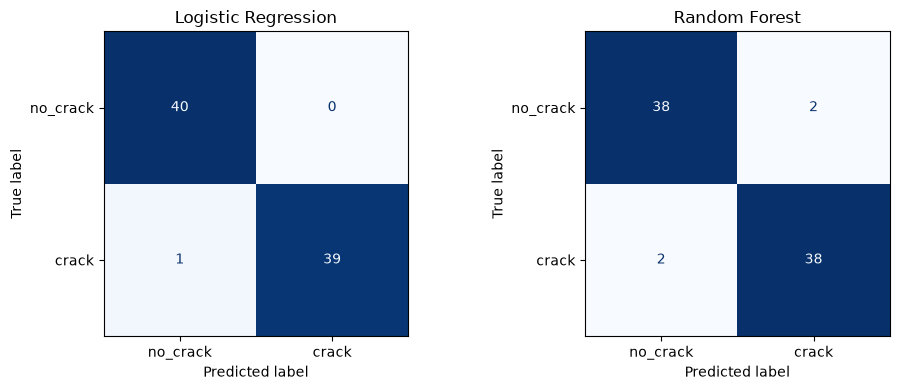

Confusion matrix layout: rows = true class, columns = predicted class
Logistic Regression:
 [[40  0]
 [ 1 39]]
Random Forest:
 [[38  2]
 [ 2 38]]


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, pred) in zip(axes, [("Logistic Regression", lr_pred), ("Random Forest", rf_pred)]):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["no_crack", "crack"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120)
plt.show()

print("Confusion matrix layout: rows = true class, columns = predicted class")
print("Logistic Regression:\n", confusion_matrix(y_test, lr_pred))
print("Random Forest:\n", confusion_matrix(y_test, rf_pred))

In [14]:
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred, target_names=["no_crack", "crack"]))
print("=== Random Forest ===")
print(classification_report(y_test, rf_pred, target_names=["no_crack", "crack"]))

print(f"Model chosen by cross-validation: {best_model_name}")
print(f"Preprocessing + feature time (test set): "
      f"{(t_preproc['test'] + t_feat['test']) / len(y_test) * 1000:.1f} ms per image")

=== Logistic Regression ===
              precision    recall  f1-score   support

    no_crack       0.98      1.00      0.99        40
       crack       1.00      0.97      0.99        40

    accuracy                           0.99        80
   macro avg       0.99      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80

=== Random Forest ===
              precision    recall  f1-score   support

    no_crack       0.95      0.95      0.95        40
       crack       0.95      0.95      0.95        40

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80

Model chosen by cross-validation: Random Forest
Preprocessing + feature time (test set): 14.1 ms per image


### Which features matter most? (Random Forest)

In [15]:
importances = pd.Series(rf_best.feature_importances_, index=feature_names).sort_values(ascending=False)
importances.head(10).round(4)

bh_mask_ratio            0.1188
bh_raw_max               0.1030
bh_total_area            0.0926
bh_raw_p99               0.0882
edge_density             0.0576
bh_raw_std               0.0558
edge_std_cell_density    0.0531
edge_count               0.0429
bh_raw_p90               0.0274
int_p95                  0.0243
dtype: float64

# Part C - Improve the Representation

**Goal:** make justified changes to the crack-image representation (Steps 3-4) so the classifier is cheaper and/or more accurate, then compare the *original* and *improved* pipelines.

**Changes tested, and why**

| Change | Justification |
|---|---|
| **Adaptive Canny thresholds** (`low = 0.67 x median`, `high = 1.33 x median` of the blurred image) | The original uses fixed thresholds 50 / 150. Asphalt brightness varies a lot between photos, so a fixed threshold finds too many edges on bright/noisy images and too few on dark ones. Thresholds tied to the image's own brightness make `edge_*` features more comparable across images. |
| **Lower resolution (256 -> 128 px)** | Every step (blur, black-hat, Otsu, Canny, connected components, percentiles) works on every pixel, so cost scales with pixel count. 128 px has 4x fewer pixels. Kernel sizes and the minimum blob area are scaled with the image so the operators cover the same *physical* area. |
| **Drop the 16 `bh_grid_*` features** | They are spatial-position features of the mask. A crack can be anywhere in the picture, so position carries little label information, while adding 16 of the 48 columns. |
| **Keep only the top-*k* features** (mutual information) | Shrinks the feature vector further; the selector is fit **inside** each CV fold so nothing leaks. |

**Method (no leakage):** every choice is made with 5-fold CV on the **training set only**. The test set is used once, at the end, to compare the original pipeline against the improved one. Both are tuned with the same grid search, so the comparison is fair.

> Important for the discussion: for classical models on ~50 features, the **model** costs milliseconds. Almost all the time is in **preprocessing + feature extraction**. So reducing the *number of features* mostly saves memory/model size, whereas reducing *resolution* is what saves wall-clock time. The measurements below test this.

In [16]:
import time
from functools import partial
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import cross_validate

cv_c = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
MODELS = ["Logistic Regression", "Random Forest"]

def odd(n):
    n = int(round(n));  return n if n % 2 == 1 else n + 1

def make_cfg(size=256, canny="fixed"):
    # Scale the image operators with the image size, so 256 reproduces the original settings exactly.
    s = size / 256
    return dict(size=size, blur=(odd(9 * s),) * 2, kernel=(odd(21 * s),) * 2,
                min_area=max(1, int(round(MIN_COMPONENT_AREA * s * s))), canny=canny)

def extract_features(imgs, cfg):
    # Full pipeline per image: resize -> gray -> blur -> black-hat -> normalize -> Otsu -> features.
    # With make_cfg(256, 'fixed') this gives exactly the same features as Steps 3-4.
    size = cfg["size"];  cell_ = size // GRID
    kern = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, cfg["kernel"])
    rows = []
    t0 = time.perf_counter()
    for img in imgs:
        img_r = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
        gray = cv2.cvtColor(img_r, cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray, cfg["blur"], 0)
        blackhat = cv2.morphologyEx(blur, cv2.MORPH_BLACKHAT, kern)
        processed = cv2.normalize(blackhat, None, 0, 255, cv2.NORM_MINMAX)
        _, mask_img = cv2.threshold(processed, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        row = {}

        g = gray.astype(np.float32);  mean, std = g.mean(), g.std()
        p5, p25, p50, p75, p95 = np.percentile(g, [5, 25, 50, 75, 95])
        z = (g - mean) / (std + 1e-8)
        hist = np.bincount(gray.ravel(), minlength=256) / gray.size;  nz = hist[hist > 0]
        row["int_mean_brightness"] = mean;  row["int_contrast_std"] = std
        row["int_min"] = g.min();  row["int_max"] = g.max();  row["int_dynamic_range"] = g.max() - g.min()
        row["int_median"] = p50
        row["int_p5"], row["int_p25"], row["int_p75"], row["int_p95"] = p5, p25, p75, p95
        row["int_iqr"] = p75 - p25
        row["int_skewness"] = (z ** 3).mean();  row["int_kurtosis"] = (z ** 4).mean() - 3.0
        row["int_entropy"] = -(nz * np.log2(nz)).sum()
        row["int_dark_ratio"] = (g < DARK_T).mean();  row["int_bright_ratio"] = (g > BRIGHT_T).mean()
        row["int_dark_ratio_rel"] = (g < mean - 1.5 * std).mean()

        if cfg["canny"] == "auto":                      # thresholds follow the image brightness
            v = float(np.median(blur));  lo, hi = int(max(0, 0.67 * v)), int(min(255, 1.33 * v))
        else:
            lo, hi = CANNY_LOW, CANNY_HIGH
        edges = cv2.Canny(blur, lo, hi)
        edge_count = np.count_nonzero(edges)
        egrid = (edges[:cell_ * GRID, :cell_ * GRID] > 0).reshape(GRID, cell_, GRID, cell_).mean(axis=(1, 3))
        row["edge_count"] = edge_count;  row["edge_density"] = edge_count / edges.size
        row["edge_max_cell_density"] = egrid.max();  row["edge_std_cell_density"] = egrid.std()

        raw = blackhat.astype(np.float32);  proc = processed.astype(np.float32)
        mask = (mask_img > 0).astype(np.uint8)
        n_lab, _, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
        areas, extents = [], []
        for j in range(1, n_lab):
            area = stats[j, cv2.CC_STAT_AREA]
            if area >= cfg["min_area"]:
                w, h = stats[j, cv2.CC_STAT_WIDTH], stats[j, cv2.CC_STAT_HEIGHT]
                areas.append(area);  extents.append(max(w, h) / size)
        row["bh_raw_mean"] = raw.mean();  row["bh_raw_std"] = raw.std();  row["bh_raw_max"] = raw.max()
        row["bh_raw_p90"] = np.percentile(raw, 90);  row["bh_raw_p99"] = np.percentile(raw, 99)
        row["bh_norm_mean"] = proc.mean();  row["bh_norm_std"] = proc.std();  row["bh_norm_p95"] = np.percentile(proc, 95)
        row["bh_mask_ratio"] = mask.mean();  row["bh_n_components"] = len(areas)
        row["bh_total_area"] = sum(areas) / (size * size)
        row["bh_largest_area"] = (max(areas) / (size * size)) if areas else 0.0
        row["bh_largest_extent"] = max(extents) if extents else 0.0
        mgrid = mask[:cell_ * GRID, :cell_ * GRID].reshape(GRID, cell_, GRID, cell_).mean(axis=(1, 3))
        for j, v_ in enumerate(mgrid.ravel()):
            row[f"bh_grid_{j:02d}"] = v_
        rows.append(row)
    return pd.DataFrame(rows), time.perf_counter() - t0

def build_model(model_name, k=None):
    sel = [("sel", SelectKBest(partial(mutual_info_classif, random_state=SEED), k=k))] if k else []
    if model_name == "Logistic Regression":
        return Pipeline([("scaler", StandardScaler())] + sel +
                        [("clf", LogisticRegression(max_iter=5000, class_weight="balanced"))])
    return Pipeline(sel + [("clf", RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                                          random_state=SEED, n_jobs=-1))])

def cv_quick(X, model_name, k=None):
    s = cross_validate(build_model(model_name, k), X, y_train, cv=cv_c, scoring=["f1", "recall", "precision"])
    return {"Model": model_name, "Features": X.shape[1] if k is None else k,
            "F1": s["test_f1"].mean(), "F1 std": s["test_f1"].std(),
            "Recall": s["test_recall"].mean(), "Precision": s["test_precision"].mean(),
            "Fit time (s)": s["fit_time"].mean()}

## C1. Extract features under each image configuration
Four extraction configurations are run on the train and test images. **A** is the original pipeline. The sanity check confirms the new extractor reproduces your original features exactly, so any difference later is due to the change, not to a rewrite.

In [17]:
IMG_CONFIGS = {"A": make_cfg(256, "fixed"), "B": make_cfg(256, "auto"),
               "C": make_cfg(128, "fixed"), "D": make_cfg(128, "auto")}
DESC = {"A": "256 px, fixed Canny (ORIGINAL)", "B": "256 px, adaptive Canny",
        "C": "128 px, fixed Canny",            "D": "128 px, adaptive Canny"}

feat = {}
for name, cfg in IMG_CONFIGS.items():
    Ftr, t_tr = extract_features(train_imgs, cfg)
    Fte, t_te = extract_features(test_imgs, cfg)
    feat[name] = {"train": Ftr, "test": Fte, "ms_per_img": (t_tr + t_te) / (len(train_imgs) + len(test_imgs)) * 1000}
    print(f"{name}: {DESC[name]:34s} | {Ftr.shape[1]} features | {feat[name]['ms_per_img']:.1f} ms per image (preprocess + features)")

same = np.allclose(feat["A"]["test"].values, X_test) and list(feat["A"]["test"].columns) == feature_names
print("\nSanity check - config A reproduces the original features exactly:", same)

A: 256 px, fixed Canny (ORIGINAL)     | 50 features | 13.4 ms per image (preprocess + features)
B: 256 px, adaptive Canny             | 50 features | 13.6 ms per image (preprocess + features)
C: 128 px, fixed Canny                | 50 features | 5.8 ms per image (preprocess + features)
D: 128 px, adaptive Canny             | 50 features | 5.8 ms per image (preprocess + features)

Sanity check - config A reproduces the original features exactly: True


### What does adaptive Canny change?
Same crack image, fixed vs adaptive thresholds, at both resolutions. Check that the crack is still visible as a thin connected line at 128 px.

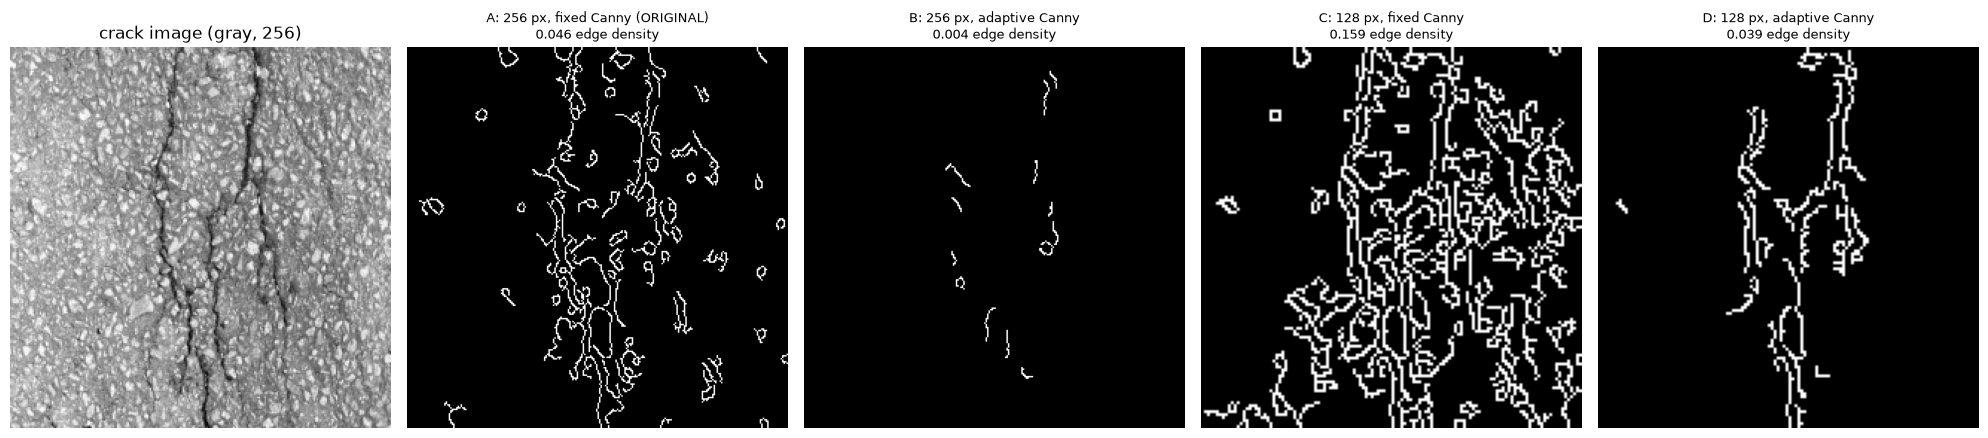

In [18]:
k0 = int(np.where(y_train == 1)[0][0])
fig, axes = plt.subplots(1, 5, figsize=(20, 4.2))
def canny_of(img, cfg):
    g = cv2.cvtColor(cv2.resize(img, (cfg["size"], cfg["size"]), interpolation=cv2.INTER_AREA), cv2.COLOR_BGR2GRAY)
    b = cv2.GaussianBlur(g, cfg["blur"], 0)
    if cfg["canny"] == "auto":
        v = float(np.median(b));  return cv2.Canny(b, int(max(0, .67 * v)), int(min(255, 1.33 * v))), g
    return cv2.Canny(b, CANNY_LOW, CANNY_HIGH), g
_, g256 = canny_of(train_imgs[k0], IMG_CONFIGS["A"])
axes[0].imshow(g256, cmap="gray"); axes[0].set_title("crack image (gray, 256)")
for ax, nm in zip(axes[1:], ["A", "B", "C", "D"]):
    e, _ = canny_of(train_imgs[k0], IMG_CONFIGS[nm]);  ax.imshow(e, cmap="gray")
    ax.set_title(f"{nm}: {DESC[nm]}\n{np.count_nonzero(e) / e.size:.3f} edge density", fontsize=9)
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

## C2. Which changes help? (5-fold CV on the training set)
Each extraction configuration (A-D) is tested with all features and without the 16 `bh_grid_*` columns. Both models use fixed, reasonable hyperparameters here (LR `C=1`, RF 200 trees) so that differences come from the representation, not from tuning.

In [19]:
grid_cols = [c for c in feat["A"]["train"].columns if c.startswith("bh_grid_")]

rows = []
for name in feat:
    for drop_grid in (False, True):
        Ftr = feat[name]["train"].drop(columns=grid_cols) if drop_grid else feat[name]["train"]
        r = {m: cv_quick(Ftr.values, m) for m in MODELS}
        rows.append({"Key": name, "Drop grid": drop_grid,
                     "Config": DESC[name] + (" | no grid" if drop_grid else " | all features"),
                     "Features": Ftr.shape[1], "Extract (ms/img)": feat[name]["ms_per_img"],
                     "CV F1 LR": r[MODELS[0]]["F1"], "CV F1 RF": r[MODELS[1]]["F1"],
                     "CV F1 mean": np.mean([r[m]["F1"] for m in MODELS]),
                     "CV Recall mean": np.mean([r[m]["Recall"] for m in MODELS]),
                     "CV fit time (s)": np.mean([r[m]["Fit time (s)"] for m in MODELS])})
abl = pd.DataFrame(rows)
abl.drop(columns=["Key", "Drop grid"]).round(4)

,Config,Features,Extract (ms/img),CV F1 LR,CV F1 RF,CV F1 mean,CV Recall mean,CV fit time (s)
0,"256 px, fixed Canny (ORIGINAL) | all features",50,13.4094,0.9623,0.9625,0.9624,0.9625,0.2710
1,"256 px, fixed Canny (ORIGINAL) | no grid",34,13.4094,0.9624,0.9660,0.9642,0.9719,0.2528
2,"256 px, adaptive Canny | all features",50,13.6403,0.9623,0.9688,0.9655,0.9656,0.2416
3,"256 px, adaptive Canny | no grid",34,13.6403,0.9624,0.9625,0.9624,0.9656,0.2354
4,"128 px, fixed Canny | all features",50,5.7560,0.9688,0.9666,0.9677,0.9812,0.2365
5,"128 px, fixed Canny | no grid",34,5.7560,0.9562,0.9663,0.9613,0.9688,0.2255
6,"128 px, adaptive Canny | all features",50,5.7627,0.9657,0.9723,0.9690,0.9750,0.2323
7,"128 px, adaptive Canny | no grid",34,5.7627,0.9562,0.9753,0.9658,0.9688,0.2704


**Choosing the improved extraction config:** among configurations whose mean CV F1 is within **0.005** of the best (i.e. no meaningful accuracy loss), take the one that is **cheapest to compute**; ties go to the one with fewer features. This rule uses training data only.

In [20]:
TOL = 0.005
cand = abl[abl["CV F1 mean"] >= abl["CV F1 mean"].max() - TOL]
pick = cand.sort_values(["Extract (ms/img)", "Features"]).iloc[0]
best_key, best_drop = pick["Key"], bool(pick["Drop grid"])
print("Chosen:", pick["Config"], f"| {int(pick['Features'])} features | CV F1 mean = {pick['CV F1 mean']:.4f} "
      f"| {pick['Extract (ms/img)']:.1f} ms/img")

def get_cols(split):
    F = feat[best_key][split]
    return F.drop(columns=grid_cols) if best_drop else F

Xtr_c, Xte_c = get_cols("train"), get_cols("test")

Chosen: 128 px, fixed Canny | all features | 50 features | CV F1 mean = 0.9677 | 5.8 ms/img


## C3. Dimensionality sweep: top-*k* features
Starting from the chosen configuration, keep only the *k* features with the highest mutual information with the label (selector fit inside each CV fold). The chosen *k* is the **smallest** *k* whose mean CV F1 (over both models) is within 0.005 of the best.

       Features      F1  Recall  Fit_time
k                                        
-1.0         50  0.9677  0.9812    0.2174
 3.0          3  0.9352  0.9312    0.4667
 5.0          5  0.9527  0.9469    0.3954
 8.0          8  0.9482  0.9438    0.3825
 10.0        10  0.9482  0.9438    0.3886
 15.0        15  0.9564  0.9594    0.3879
 20.0        20  0.9621  0.9625    0.3891
 25.0        25  0.9613  0.9688    0.3956
 30.0        30  0.9660  0.9750    0.3986
 40.0        40  0.9675  0.9750    0.4011

Chosen k = 30 of 50 (30 features, mean CV F1 = 0.9660)


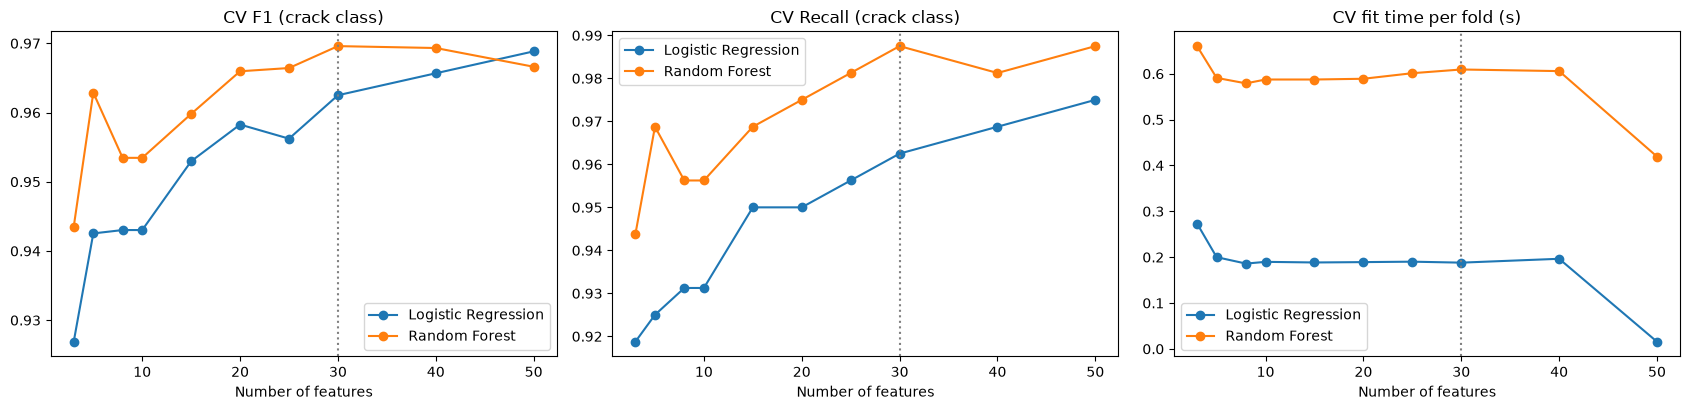

In [21]:
n_feat = Xtr_c.shape[1]
KS = [k for k in [3, 5, 8, 10, 15, 20, 25, 30, 40] if k < n_feat]

rows = []
for m in MODELS:
    for k in KS + [None]:
        rows.append({"k": np.nan if k is None else k, **cv_quick(Xtr_c.values, m, k)})
sweep = pd.DataFrame(rows)

by_k = sweep.groupby(sweep["k"].fillna(-1)).agg(Features=("Features", "first"), F1=("F1", "mean"),
                                                 Recall=("Recall", "mean"), Fit_time=("Fit time (s)", "mean"))
ok = by_k[by_k["F1"] >= by_k["F1"].max() - TOL].sort_values("Features").iloc[0]
K_BEST = None if ok["Features"] >= n_feat else int(ok["Features"])
print(by_k.round(4).to_string())
print(f"\nChosen k = {K_BEST if K_BEST else 'all'} of {n_feat} ({int(ok['Features'])} features, mean CV F1 = {ok['F1']:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
for m in MODELS:
    d = sweep[sweep["Model"] == m].sort_values("Features")
    axes[0].plot(d["Features"], d["F1"], marker="o", label=m)
    axes[1].plot(d["Features"], d["Recall"], marker="o", label=m)
    axes[2].plot(d["Features"], d["Fit time (s)"], marker="o", label=m)
for ax, t in zip(axes, ["CV F1 (crack class)", "CV Recall (crack class)", "CV fit time per fold (s)"]):
    ax.set_xlabel("Number of features"); ax.set_title(t); ax.legend()
    if K_BEST: ax.axvline(K_BEST, ls=":", color="gray")
plt.tight_layout(); plt.show()

## C4. Original vs improved on the held-out test set
Both pipelines get the **same** tuning as Step 5 (5-fold grid search on the training set, scoring = F1). The improved pipeline runs the feature selector *inside* the grid search, so it is leak-free. Reported times:

- **Extraction** = resize + preprocessing + feature computation, per image
- **Tuning / training** = whole grid search / refit of the best model
- **Prediction** = `.predict()` per image (mean of 5 runs)
- **End-to-end per image** = extraction + prediction: the real cost of classifying a new photo

In [22]:
def tune_and_eval(Xtr, Xte, k, extract_ms):
    out = {}
    specs = {"Logistic Regression": {"clf__C": [0.01, 0.1, 1, 10, 100]},
             "Random Forest": {"clf__n_estimators": [100, 300], "clf__max_depth": [None, 5, 10],
                               "clf__min_samples_leaf": [1, 3]}}
    for m, grid in specs.items():
        gs = GridSearchCV(build_model(m, k), grid, cv=cv_c, scoring="f1", n_jobs=-1)
        t0 = time.perf_counter(); gs.fit(Xtr, y_train); tune = time.perf_counter() - t0
        best = gs.best_estimator_
        ts = []
        for _ in range(5):
            t0 = time.perf_counter(); pred = best.predict(Xte); ts.append(time.perf_counter() - t0)
        pred_ms_img = np.mean(ts) * 1000 / len(y_test)
        proba = best.predict_proba(Xte)[:, 1]
        out[m] = {"Features": Xtr.shape[1] if k is None else k, "CV F1 (train)": gs.best_score_,
                  "Accuracy": accuracy_score(y_test, pred), "Precision": precision_score(y_test, pred),
                  "Recall": recall_score(y_test, pred), "F1": f1_score(y_test, pred),
                  "ROC-AUC": roc_auc_score(y_test, proba),
                  "Extraction (ms/img)": extract_ms, "Tuning (s)": tune, "Training (s)": gs.refit_time_,
                  "Prediction (ms/img)": pred_ms_img, "End-to-end (ms/img)": extract_ms + pred_ms_img,
                  "_cm": confusion_matrix(y_test, pred)}
    return out

orig = tune_and_eval(feat["A"]["train"].values, feat["A"]["test"].values, None, feat["A"]["ms_per_img"])
impr = tune_and_eval(Xtr_c.values, Xte_c.values, K_BEST, feat[best_key]["ms_per_img"])

final = pd.DataFrame([{"Model": m, "Version": v, **{k_: x for k_, x in d[m].items() if k_ != "_cm"}}
                      for v, d in [("Original", orig), ("Improved", impr)] for m in MODELS])
final.round(4)

,Model,Version,Features,CV F1 (train),Accuracy,Precision,Recall,F1,ROC-AUC,Extraction (ms/img),Tuning (s),Training (s),Prediction (ms/img),End-to-end (ms/img)
0,Logistic Regression,Original,50,0.9623,0.9875,1.0000,0.975,0.9873,1.0000,13.4094,0.1709,0.0206,0.0106,13.4199
1,Random Forest,Original,50,0.9655,0.9500,0.9500,0.950,0.9500,0.9909,13.4094,4.7660,0.2540,0.5418,13.9512
2,Logistic Regression,Improved,30,0.9690,0.9625,0.9512,0.975,0.9630,0.9981,5.7560,0.8769,0.1868,0.0103,5.7662
3,Random Forest,Improved,30,0.9696,0.9375,0.9268,0.950,0.9383,0.9925,5.7560,6.6687,0.7860,1.1299,6.8859


In [23]:
delta = []
for m in MODELS:
    o, i = orig[m], impr[m]
    delta.append({"Model": m, "Features": f"{o['Features']} -> {i['Features']}",
                  "Feature reduction %": 100 * (1 - i["Features"] / o["Features"]),
                  "Delta F1": i["F1"] - o["F1"], "Delta Recall": i["Recall"] - o["Recall"],
                  "Delta Precision": i["Precision"] - o["Precision"], "Delta ROC-AUC": i["ROC-AUC"] - o["ROC-AUC"],
                  "Extraction speed-up (x)": o["Extraction (ms/img)"] / i["Extraction (ms/img)"],
                  "Training speed-up (x)": o["Training (s)"] / i["Training (s)"],
                  "Prediction speed-up (x)": o["Prediction (ms/img)"] / i["Prediction (ms/img)"],
                  "End-to-end speed-up (x)": o["End-to-end (ms/img)"] / i["End-to-end (ms/img)"]})
delta = pd.DataFrame(delta)
delta.round(4)

,Model,Features,Feature reduction %,Delta F1,Delta Recall,Delta Precision,Delta ROC-AUC,Extraction speed-up (x),Training speed-up (x),Prediction speed-up (x),End-to-end speed-up (x)
0,Logistic Regression,50 -> 30,40.0,-0.0244,0.0,-0.0488,-0.0019,2.3297,0.1105,1.0259,2.3273
1,Random Forest,50 -> 30,40.0,-0.0117,0.0,-0.0232,0.0016,2.3297,0.3232,0.4795,2.0261


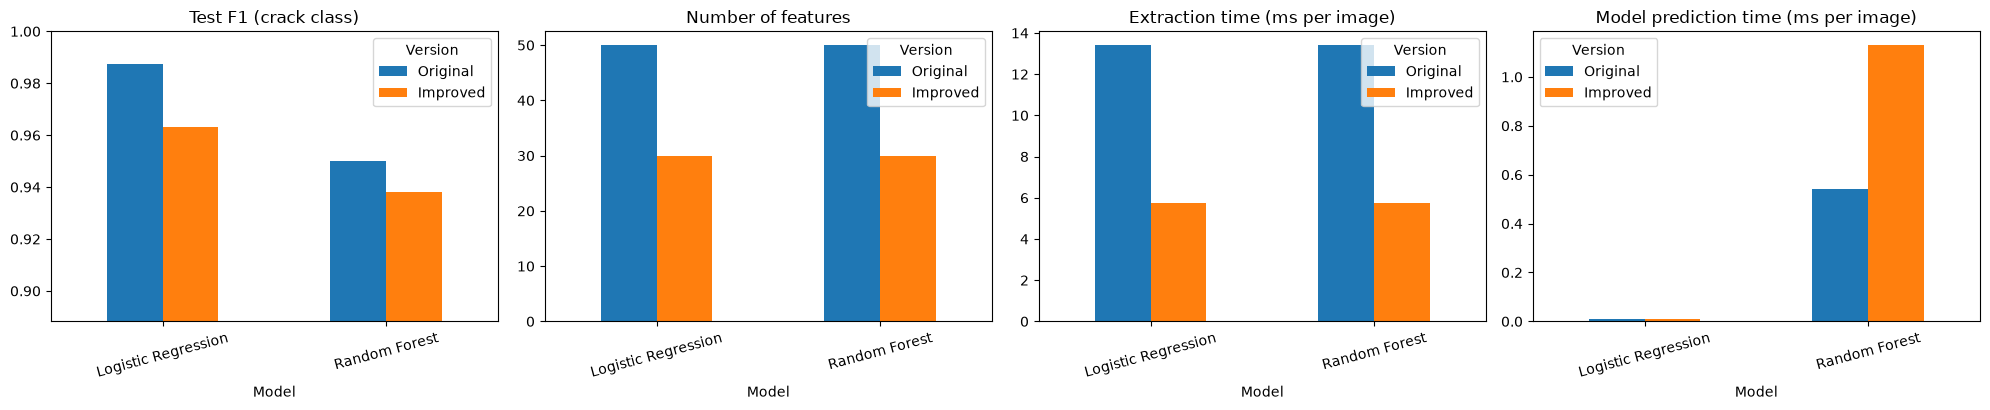

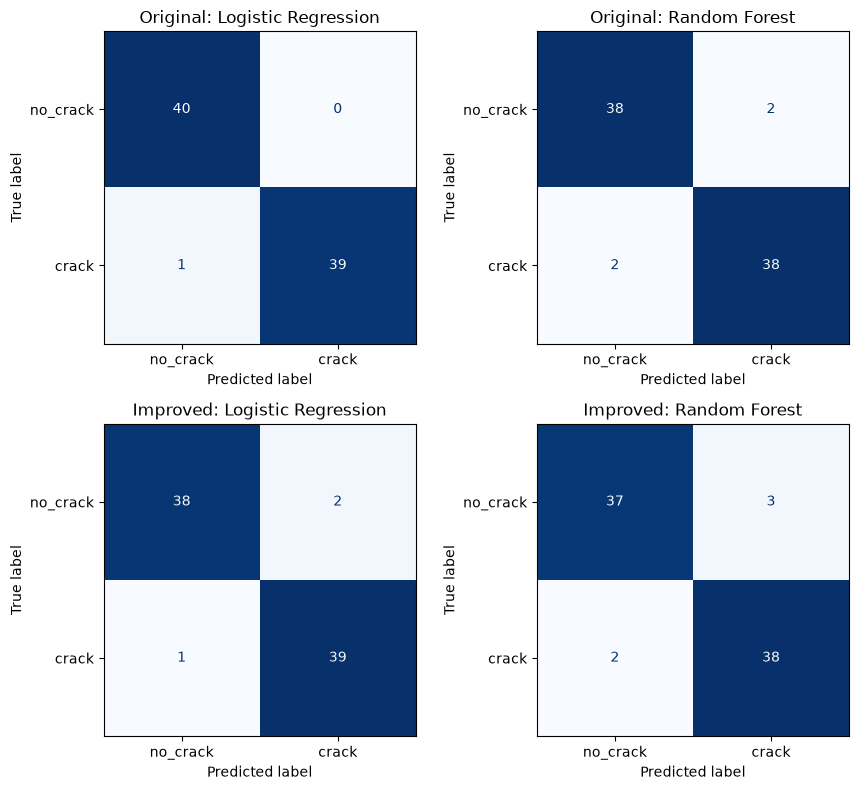

In [24]:
pv = lambda col: final.pivot(index="Model", columns="Version", values=col)[["Original", "Improved"]]
fig, axes = plt.subplots(1, 4, figsize=(20, 4.2))
pv("F1").plot(kind="bar", ax=axes[0], rot=15);                   axes[0].set_title("Test F1 (crack class)")
axes[0].set_ylim(max(0, final["F1"].min() - 0.05), 1.0)
pv("Features").plot(kind="bar", ax=axes[1], rot=15);             axes[1].set_title("Number of features")
pv("Extraction (ms/img)").plot(kind="bar", ax=axes[2], rot=15);  axes[2].set_title("Extraction time (ms per image)")
pv("Prediction (ms/img)").plot(kind="bar", ax=axes[3], rot=15);  axes[3].set_title("Model prediction time (ms per image)")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for r_i, (v, d) in enumerate([("Original", orig), ("Improved", impr)]):
    for c_i, m in enumerate(MODELS):
        ConfusionMatrixDisplay(d[m]["_cm"], display_labels=["no_crack", "crack"]).plot(ax=axes[r_i, c_i], cmap="Blues", colorbar=False)
        axes[r_i, c_i].set_title(f"{v}: {m}")
plt.tight_layout(); plt.show()

## C5. Discussion: feature dimensionality vs computation time vs performance
The cell below prints the key numbers from *your* run so the discussion matches the tables.

In [25]:
print(f"Improved pipeline: {DESC[best_key]}; grid features {'dropped' if best_drop else 'kept'}; "
      f"top-k = {K_BEST if K_BEST else 'all'}\n")
for m in MODELS:
    o, i, d = orig[m], impr[m], delta[delta.Model == m].iloc[0]
    n_pos = int((y_test == 1).sum());  dn = int(round(i["Recall"] * n_pos)) - int(round(o["Recall"] * n_pos))
    print(f"- {m}: features {o['Features']} -> {i['Features']} ({d['Feature reduction %']:.0f}% fewer); "
          f"F1 {o['F1']:.3f} -> {i['F1']:.3f} ({d['Delta F1']:+.3f}); recall {o['Recall']:.3f} -> {i['Recall']:.3f} "
          f"({dn:+d} cracks caught); AUC {o['ROC-AUC']:.3f} -> {i['ROC-AUC']:.3f}")
    print(f"    extraction {o['Extraction (ms/img)']:.1f} -> {i['Extraction (ms/img)']:.1f} ms/img ({d['Extraction speed-up (x)']:.2f}x), "
          f"prediction {o['Prediction (ms/img)']:.4f} -> {i['Prediction (ms/img)']:.4f} ms/img ({d['Prediction speed-up (x)']:.2f}x), "
          f"training {o['Training (s)']:.3f} -> {i['Training (s)']:.3f} s ({d['Training speed-up (x)']:.2f}x), "
          f"end-to-end {d['End-to-end speed-up (x)']:.2f}x")

share = feat[best_key]["ms_per_img"] / impr[MODELS[1]]["End-to-end (ms/img)"] * 100
print(f"\nExtraction is {share:.1f}% of the improved end-to-end time per image (prediction is the rest).")
print(f"Test set: {len(y_test)} images ({int(y_test.sum())} cracks). One image is worth about "
      f"{100 / int(y_test.sum()):.1f} points of recall, so very small differences are within noise.")

Improved pipeline: 128 px, fixed Canny; grid features kept; top-k = 30

- Logistic Regression: features 50 -> 30 (40% fewer); F1 0.987 -> 0.963 (-0.024); recall 0.975 -> 0.975 (+0 cracks caught); AUC 1.000 -> 0.998
    extraction 13.4 -> 5.8 ms/img (2.33x), prediction 0.0106 -> 0.0103 ms/img (1.03x), training 0.021 -> 0.187 s (0.11x), end-to-end 2.33x
- Random Forest: features 50 -> 30 (40% fewer); F1 0.950 -> 0.938 (-0.012); recall 0.950 -> 0.950 (+0 cracks caught); AUC 0.991 -> 0.992
    extraction 13.4 -> 5.8 ms/img (2.33x), prediction 0.5418 -> 1.1299 ms/img (0.48x), training 0.254 -> 0.786 s (0.32x), end-to-end 2.03x

Extraction is 83.6% of the improved end-to-end time per image (prediction is the rest).
Test set: 80 images (40 cracks). One image is worth about 2.5 points of recall, so very small differences are within noise.
